In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# 1. Load and clean data
def load_and_clean(file_path):
    df = pd.read_csv(file_path)
    df = df[df['Date'].notna()]
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df[df['Date'].notna()]
    return df

df_2020 = load_and_clean("extracted-sheets/2020-Daily Traffic Summary.csv")
df_2021 = load_and_clean("extracted-sheets/2021-Daily Traffic Summary.csv")
df_2022 = load_and_clean("extracted-sheets/2022-Daily Traffic Summary.csv")
df_2023 = load_and_clean("extracted-sheets/2023-Daily Traffic Summary.csv")
df_2024 = load_and_clean("extracted-sheets/2024-Daily Traffic Summary.csv")

all_df = pd.concat([df_2020, df_2021, df_2022, df_2023, df_2024], ignore_index=True)
all_df = all_df.drop_duplicates(subset=['Date']).sort_values('Date').reset_index(drop=True)

target_station = '3-026'
all_df[target_station] = pd.to_numeric(all_df[target_station].astype(str).str.strip().replace(['no data', 'nan', 'None', ''], np.nan), errors='coerce')

all_df.set_index('Date', inplace=True)
all_df = all_df.asfreq('D')
all_df[target_station] = all_df[target_station].interpolate(method='linear')

# NOTE: expand training to include 2023 and set test to 2024
train_series = all_df.loc['2020-01-01':'2022-12-31', target_station]
test_series = all_df.loc['2023-01-01':'2023-12-31', target_station]

# Step 1: Stationarity Test (ADF)
adf_raw = adfuller(train_series)
print("ADF on Raw Data:")
print(f"Stat: {adf_raw[0]:.4f}, p-value: {adf_raw[1]:.4f}")

# Try weekly difference due to seasonality (S=7)
diff_7 = train_series.diff(7).dropna()
adf_diff7 = adfuller(diff_7)
print("\nADF on 7-day Differenced Data:")
print(f"Stat: {adf_diff7[0]:.4f}, p-value: {adf_diff7[1]:.4f}")

# Try first difference of 7-day difference
diff_1_7 = diff_7.diff(1).dropna()
adf_diff1_7 = adfuller(diff_1_7)
print("\nADF on First + 7-day Differenced Data:")
print(f"Stat: {adf_diff1_7[0]:.4f}, p-value: {adf_diff1_7[1]:.4f}")

ADF on Raw Data:
Stat: -3.0653, p-value: 0.0292

ADF on 7-day Differenced Data:
Stat: -6.8454, p-value: 0.0000

ADF on First + 7-day Differenced Data:
Stat: -11.8799, p-value: 0.0000


#### 1. Kiểm định Augmented Dickey-Fuller (ADF Test)

Để kiểm tra tính dừng một cách khách quan thay vì nhìn bằng mắt thường, người ta sử dụng kiểm định giả thuyết toán học ADF dựa trên phương trình hồi quy sai phân sau:

$$\Delta Y_t = \alpha + \beta t + \gamma Y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta Y_{t-i} + \epsilon_t$$

**Trong đó:**

* $\Delta Y_t = Y_t - Y_{t-1}$: Là sai phân bậc 1 của chuỗi tại thời điểm $t$.
* $\alpha$: Hằng số (hệ số chặn / drift).
* $\beta t$: Thành phần xu hướng theo thời gian (deterministic trend).
* $Y_{t-1}$: Giá trị trễ (lag 1) của chuỗi thời gian.
* $\gamma$: **Hệ số quan trọng nhất dùng để kiểm định.** Nếu $\gamma = 0$, chuỗi chứa một nghiệm đơn vị (unit root) và dịch chuyển không ngừng.
* $\delta_i$: Hệ số của các sai phân trễ bậc $i$ (được thêm vào nhằm triệt tiêu hiện tượng tự tương quan của nhiễu).
* $\epsilon_t$: Nhiễu trắng (white noise) có trung bình bằng 0.

**Cặp giả thuyết kiểm định:**

* **Giả thuyết Không $H_0: \gamma = 0$**: Chuỗi dữ liệu có nghiệm đơn vị $\rightarrow$ Chuỗi **KHÔNG DỪNG** (Non-stationary).
* **Giả thuyết Đối $H_1: \gamma < 0$**: Chuỗi dữ liệu **DỪNG** (Stationary).

**Quy tắc ra quyết định:**

* Nếu giá trị $p\text{-value} \le 0.05$ (hoặc giá trị Thống kê ADF nhỏ hơn Giá trị tới hạn ở mức 5%): Bác bỏ giả thuyết $H_0$ $\rightarrow$ Kết luận chuỗi dữ liệu **ĐÃ DỪNG** (có thể đưa vào ARIMA).
* Nếu $p\text{-value} > 0.05$: Không thể bác bỏ $H_0$ $\rightarrow$ Chuỗi **KHÔNG DỪNG** (cần phải lấy sai phân tiếp).

#### 2. Hàm tự tương quan (ACF) và Tự tương quan riêng phần (PACF)

Sau khi chuỗi đạt tính dừng, ta cần vẽ đồ thị ACF và PACF để xác định các tham số $(p, q)$ và $(P, Q)_s$:

* **ACF (Autocorrelation Function):** Đo lường mức độ tương quan giữa giá trị hiện tại $Y_t$ và các giá trị quá khứ $Y_{t-k}$ (bao gồm cả các tác động gián tiếp xuyên suốt các khoảng thời gian ở giữa). Thường dùng để xác định bậc trung bình trượt $q$ (MA).
* **PACF (Partial Autocorrelation Function):** Đo lường mối tương quan trực tiếp giữa $Y_t$ và $Y_{t-k}$ sau khi đã **loại bỏ** hoàn toàn ảnh hưởng gián tiếp của các độ trễ ngắn hơn nằm ở giữa. Thường dùng để xác định bậc tự hồi quy $p$ (AR).



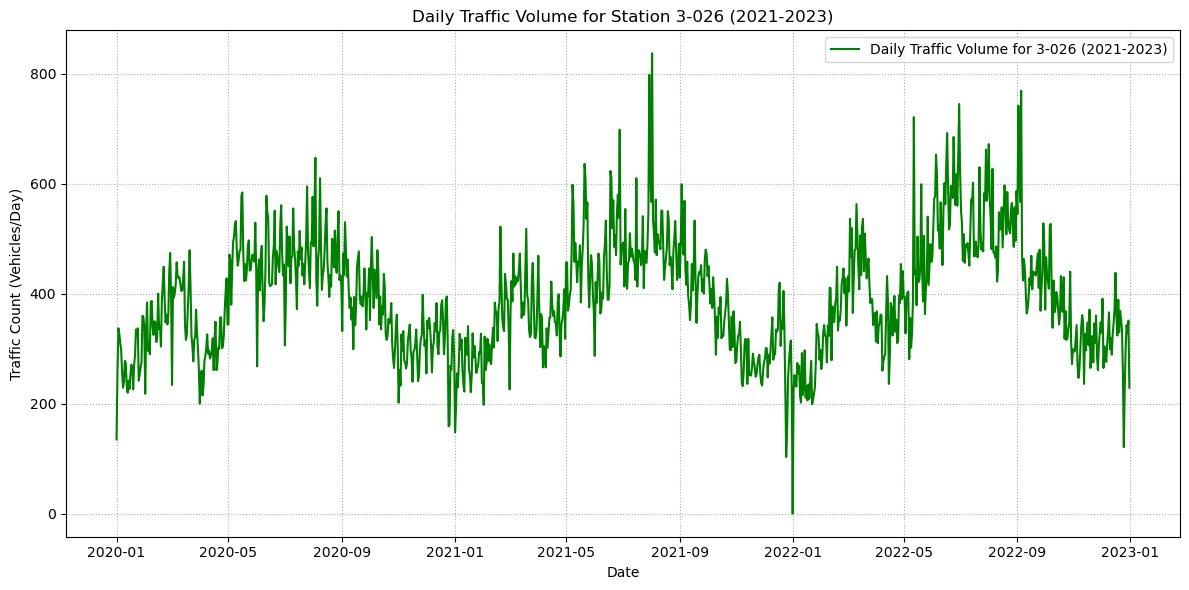

In [12]:
# --- VẼ LẠI ĐỒ THỊ CHUẨN ---
plt.figure(figsize=(12, 6))
plt.plot(train_series.index, train_series, label=f'Daily Traffic Volume for {target_station} (2021-2023)', color='green')
plt.title(f'Daily Traffic Volume for Station {target_station} (2021-2023)')
plt.xlabel('Date')
plt.ylabel('Traffic Count (Vehicles/Day)')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
import warnings
warnings.filterwarnings("ignore")

best_aic = float("inf")
best_order = None
best_seasonal_order = None
best_model = None

# Grid search parameters
p_range = [0, 1, 2]
d_range = [0, 1]
q_range = [0, 1, 2]
P_range = [0, 1]
D_range = [1]
Q_range = [0, 1]
S = 7

for p in p_range:
    for d in d_range:
        for q in q_range:
            for P in P_range:
                for D in D_range:
                    for Q in Q_range:
                        try:
                            model = SARIMAX(train_series,
                                            order=(p, d, q),
                                            seasonal_order=(P, D, Q, S),
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
                            results = model.fit(disp=False)
                            if results.aic < best_aic:
                                best_aic = results.aic
                                best_order = (p, d, q)
                                best_seasonal_order = (P, D, Q, S)
                                best_model = results
                        except:
                            continue

print(f"Best SARIMA Order: {best_order}")
print(f"Best Seasonal Order: {best_seasonal_order}")
print(f"Best AIC: {best_aic:.2f}")
print(best_model.summary())

Best SARIMA Order: (1, 1, 2)
Best Seasonal Order: (1, 1, 1, 7)
Best AIC: 11624.81
                                      SARIMAX Results                                      
Dep. Variable:                               3-026   No. Observations:                 1096
Model:             SARIMAX(1, 1, 2)x(1, 1, [1], 7)   Log Likelihood               -5806.406
Date:                             Mon, 25 May 2026   AIC                          11624.811
Time:                                     18:19:57   BIC                          11654.708
Sample:                                 01-01-2020   HQIC                         11636.133
                                      - 12-31-2022                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4617   

Mô hình SARIMA đầy đủ có dạng cấu hình tổng quát là:


$$\text{SARIMA}(p, d, q) \times (P, D, Q)_s$$

**Trong đó:**

* **Phần phi mùa vụ (Non-seasonal):** $p$ (Bậc tự hồi quy AR), $d$ (Bậc sai phân tổng thể - ở Bước 2 ta xác định $d=0$), $q$ (Bậc trung bình trượt MA).
* **Phần mùa vụ (Seasonal):** $P$ (Bậc tự hồi quy mùa vụ), $D$ (Bậc sai phân mùa vụ - ở đây $D=0$ do dữ liệu gốc đã dừng), $Q$ (Bậc trung bình trượt mùa vụ).
* **$s = 7$:** Độ dài chu kỳ mùa vụ tính theo ngày (Tuần tuần hoàn 7 ngày).

#### Tiêu chí đánh giá toán học: AIC (Akaike Information Criterion)

Để biết cấu hình nào (ví dụ giữa $\text{SARIMA}(1,0,1)\times(1,0,0)_7$ và $\text{SARIMA}(2,0,2)\times(1,0,1)_7$) là tối ưu nhất, thuật toán sẽ dựa trên chỉ số **AIC** được tính bằng công thức:

$$\text{AIC} = 2k - 2\ln(\hat{L})$$

**Ý nghĩa các thành phần:**

* $k$: Số lượng tham số mà mô hình phải ước lượng (Càng nhiều tham số, mô hình càng cồng kềnh và dễ bị quá khớp - Overfitting).
* $\hat{L}$: Giá trị cực đại của hàm hợp lý (Maximum Likelihood) của mô hình (Đo lường mức độ khớp/giải thích dữ liệu của mô hình).

**Quy tắc chọn tham số:** Mục tiêu của thuật toán Quét lưới (Grid Search) là tìm ra tổ hợp tham số sao cho **chỉ số AIC đạt giá trị NHỎ NHẤT**. Công thức AIC đóng vai trò như một cán cân: Nó vừa phạt mô hình nếu cố tình thêm quá nhiều tham số phụ ($2k$), vừa thưởng nếu mô hình khớp tốt với dữ liệu ($-2\ln(\hat{L})$). Cấu hình đạt AIC thấp nhất chính là điểm cân bằng hoàn hảo.



In [14]:
# Forecast the 2024 test period using the best fitted SARIMA model
n_forecast = len(test_series)
forecast_res = best_model.get_forecast(steps=n_forecast)
forecast_values = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int(alpha=0.05)

print("Generated forecast_values and forecast_ci for the 2024 test period.")

Generated forecast_values and forecast_ci for the 2024 test period.


In [15]:
print(len(test_series))

365


In [16]:
# Cắt ngắn dữ liệu dự báo về đúng 60 ngày đầu để khớp với test_series
actual = test_series.values
predicted = pd.Series(forecast_values).values[:len(test_series)]

# Tính toán MAE và RMSE mượt mà
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# Tính toán MAPE loại bỏ các ngày có giá trị bằng 0 (nếu có)
mask = actual > 0
mape_clean = mean_absolute_percentage_error(actual[mask], predicted[mask]) * 100
print(f"Cleaned MAPE (excluding 0 values): {mape_clean:.2f}%")

MAE: 243.44
RMSE: 338.57
Cleaned MAPE (excluding 0 values): 54.59%


Plot saved successfully: traffic_forecast_3026_actual.png


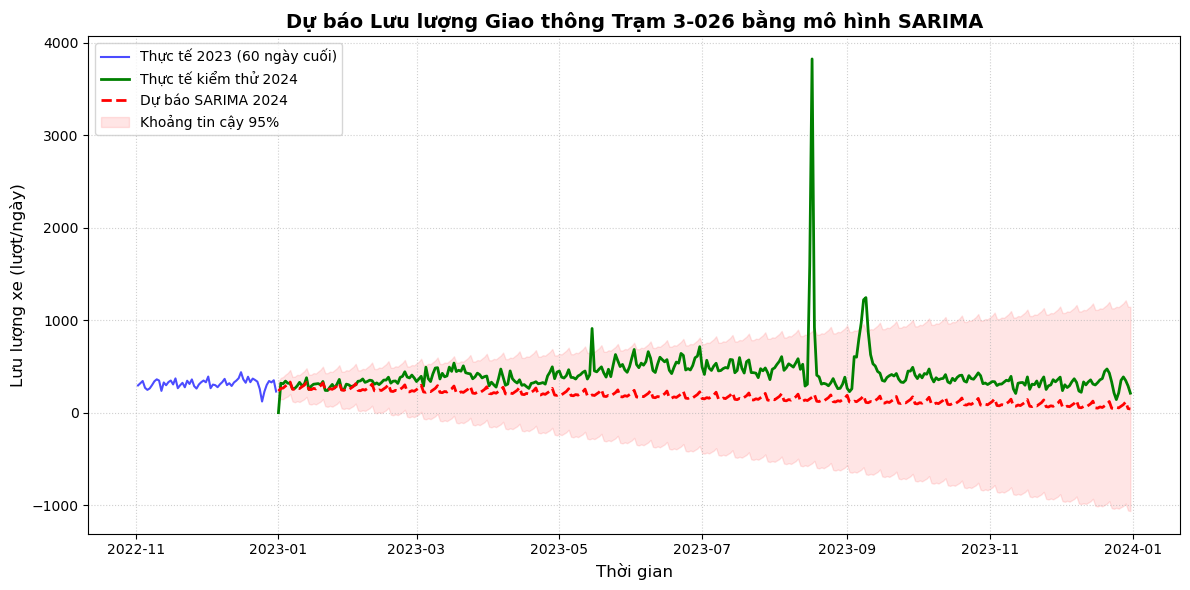

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train_series.tail(60), label='Thực tế 2023 (60 ngày cuối)', color='blue', alpha=0.7)
ax.plot(test_series, label='Thực tế kiểm thử 2024', color='green', linewidth=2)
ax.plot(test_series.index, forecast_values[:len(test_series)], label='Dự báo SARIMA 2024', color='red', linestyle='--', linewidth=2)
if 'forecast_ci' in globals() and forecast_ci is not None:
    ax.fill_between(test_series.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='red', alpha=0.1, label='Khoảng tin cậy 95%')
ax.set_title(f"Dự báo Lưu lượng Giao thông Trạm {target_station} bằng mô hình SARIMA", fontsize=14, fontweight='bold')
ax.set_xlabel("Thời gian", fontsize=12)
ax.set_ylabel("Lưu lượng xe (lượt/ngày)", fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
# Save plot using station id to avoid hard-coded name
filename = f"traffic_forecast_{target_station.replace('-', '')}_actual.png"
plt.savefig(filename)
print(f"Plot saved successfully: {filename}")